# **BB84 QKD** 
#### *Implementation in Qiskit with intercept-resend eavesdropper analysis*

## **§1 - Introduction**

Since its invention in the 1970s, public key cryptosystems have been widely adopted for encryption and secure communication on the internet. However, the security of these cryptosystems ultimately relies on assumptions about the difficulty of certain mathematical problems, and hence such cryptosystems are not _provably_ secure. 

The advent of quantum computing has brought with it the greatest threat to public key cryptosystems - _Shor's Algorithm_. With a sufficiently powerful fault-tolerent quantum computer, _Shor's Algorithm_ can be used to solve the integer factorisation problem, the discrete logarithm problem and the elliptic-curve discrete logarithm problem - breaking essentially every type of public key cryptography. Despite the limitations of current quantum computing hardware, this fundamental vulnerability of public key cryptosystems has raised serious questions about their future security. 

Thankfully, quantum information theory has given us a much more powerful cryptographic tool. The BB84 QKD protocol is a _provably secure_ procedure for two parties to establish a shared private key over public channels (classical + quantum). As long as qubits can be transmitted over the public channel with a sufficiently low error rate, the security of the resulting key is garunteed by the laws of quantum mechanics. This secret key can then be used to encrypt messages using a simple one time pad, which then enables _provably secure_ communication between the two parties. 

The following is an overview of the BB84 QKD protocol including an implementation in Qiskit with intecept-resend eavesdropping attack analysis.

## **§2 - The BB84 Protocol**

The BB84 QKD Protocol between Alice and Bob is as follows: 

1. Alice generates two $n$-bit strings $\mathbf{x}$ & $\mathbf{y}$ uniformly at random
$$ \mathbf{x} = x_1 x_2 x_3 ... \in  \{0,1\} ^{n}$$
$$ \mathbf{y} = y_1 y_2 y_3 ... \in  \{0,1\} ^{n}$$

2. Alice then prepares $n$ qubits in the states $|\psi_{x_i y_i}\rangle$ defined by $$|\psi_{x_i 0}\rangle  = \left\{\begin{matrix}
|0\rangle \text{  } x_i = 0
 \\
|1\rangle \text{  } x_i = 1
\end{matrix}\right.$$ $$|\psi_{x_i 1}\rangle  = \left\{\begin{matrix}
|+\rangle \text{  } x_i = 0
 \\
|-\rangle \text{  } x_i = 1
\end{matrix}\right.$$ 
and sends them all to Bob. 

3. Bob generates his own $n$-bit string $\mathbf{y'}$ uniformly at random $$ \mathbf{y'} = y'_1 y'_2 y'_3 ... \in  \{0,1\} ^{n}$$ He then measures each of the qubits from Alice as follows: $$ y'_i = 0 \Rightarrow \text{ measure } |\psi_{x_i y_i}\rangle \text{ in basis } \{|0\rangle, |1\rangle\}$$ $$ y'_i = 1 \Rightarrow \text{ measure } |\psi_{x_i y_i}\rangle \text{ in basis }\{|+\rangle, |-\rangle\} $$ and writes his measurement outcomes as a bit string $\mathbf{x'} = x'_1 x'_2 x'_3 ...$ $$ $$
Now, given Alice's qubit encoding of $\mathbf{x}$ and Bob's choice of measurement basis for each qubit, he knows that $$ y'_i = y_i \Rightarrow x'_i = x_i$$ Since Bob chose $\mathbf{y'}$ uniformly at random, he expects $x'_i = x_i$ for about $\frac{n}{2}$ bits.

4. Alice and Bob then compare $\mathbf{y}$ and $\mathbf{y'}$ over the classical channel and discard any $x_i$ and $x'_i$ for which $y_i ≠ y'_i$. They should then both be left with shorter bit strings $\mathbf{\tilde{x}}$ and $\mathbf{\tilde{x}}'$ with an expected length of $\frac{n}{2}$.

In the case of a noiseless and secure quantum channel, these bit strings would be identical. In reality, Alice and Bob expect errors to arise from noise and interference by Eve.

## **§3 - Security of BB84**

The security of BB84 (and QKD protocols in general) follows from the fact that Eve cannot gain any information from the qubits transmitted from Alice to Bob without disturbing their states. This is due to two fundamental results of quantum information theory:

1. __**The No-Cloning Theorem**__

    **Formal statement**: *Let $S$ be a set of quantum states containing at least one non-orthogonal pair. Then $\nexists$ a unitary cloning process that achives cloning $\forall$ states in $S$*.

    In other words, given an arbitary *unkown* state $|\psi\rangle$ from a set of *known* states $S$ containing at least one non-orthogonal pair, there does not exist a general unitary cloning process that can clone $|\psi\rangle$.

    **Implication for QKD**: Since the four states used in BB84 contain two non-orthogonal pairs, it is not possible for Eve to clone the intercepted qubit. If Eve could clone the intercepted qubit an arbitary number of times and measure the clones, she could learn the qubit's state whilst resending the original qubit unchanged. 

2. __**Information Gain Implies Disturbance**__

    **Formal Statement**: *In any attempt to distinguish between two non-orthogonal quantum states, information gain is only possible at the expense of disurbing the states.*

    **Implication for QKD**: If Eve intercepts Alice's qubit and makes any attempt to gain information about its state before resending it to Bob, this will inevtiably disturb the qubit's state. By transmitting a series of control qubits randomly distrubited among the encoded qubits, Bob can measure these qubits and compare his results with Alice to detect eavesdropping in their channel and establish an upper bound on its disturbance. If the level of eavedropping is deemed too significant, Alice and Bob can simply abandon their secret keys rendering Eve's interference futile.

## **§4 - Implementation**

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qkdcode.channel import QuantumChannel
from qkdcode.bb84 import Alice, Bob, run_bb84
from qkdcode.eavesdropping import RandomInterceptResendEve, BreidbartEve, BB84AttackRecord, compare_bb84_attacks
seed = 42
rng = np.random.default_rng(seed)

### **§4.1 State Preparation In Qiskit** 

Alice perpares her qubits in the states $|0\rangle, |1\rangle, |+\rangle, |-\rangle$. In Qiskit, these states are prepared by applying an appropriate combination of $X$ and $H$ gates. 
- The $X$ gate flips the qubit from $0$ to $1$.
- The $H$ gate rotates the qubit to the Bell basis.

The circuits for each of these states are demonstrated below:

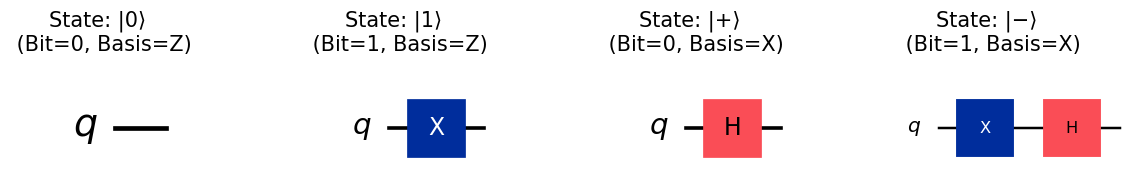

In [2]:
states = {
    'State: |0⟩ \n (Bit=0, Basis=Z)': (0, 0),
    'State: |1⟩ \n (Bit=1, Basis=Z)': (1, 0),
    'State: |+⟩ \n (Bit=0, Basis=X)': (0, 1),
    'State: |−⟩ \n (Bit=1, Basis=X)': (1, 1),
}
fig, axes = plt.subplots(1, 4, figsize=(12, 2))
for ax, (label, (bit, basis)) in zip(axes, states.items()):
    qc = QuantumCircuit(1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    qc.draw('mpl', ax=ax)
    ax.set_title(label, fontsize=15)
plt.tight_layout()

Using the above preparation of the states $|0\rangle, |1\rangle, |+\rangle, |-\rangle$, the function `encode_qubits()` within the `Alice` class encodes her bits according to her bases. Below we verify this encoding for each possible state.

In [2]:
alice_test = Alice(num_bits=1, rng=rng)

# Verifying encoding of bit=0, basis=Z in |0⟩
alice_test.bits = np.array([0])
alice_test.bases = np.array([0])
circuit = alice_test.encode_qubits()[0]

sv = Statevector.from_instruction(circuit)
print("Bit = 0, Basis = Z")
print("------------------")
print(f"Encoded state: {sv[0]:.3f}, {sv[1]:.3f}")
print(f"Expected |0⟩: [1+0j, 0+0j]")
assert np.allclose(sv.data, [1, 0], atol=1e-10)
print("✓ Encoding verified\n")

# Verifying encoding of bit=1, basis=Z in |1⟩
alice_test.bits = np.array([1])
alice_test.bases = np.array([0])
circuit = alice_test.encode_qubits()[0]

sv = Statevector.from_instruction(circuit)
print("Bit = 1, Basis = Z")
print("------------------")
print(f"Encoded state: {sv[0]:.3f}, {sv[1]:.3f}")
print(f"Expected |1⟩: [0+0j, 1+0j]")
assert np.allclose(sv.data, [0, 1], atol=1e-10)
print("✓ Encoding verified\n")

# Verifying encoding of bit=0, basis = X in |+⟩ = [1/√2, 1/√2]
alice_test.bits = np.array([0])
alice_test.bases = np.array([1])
circuit = alice_test.encode_qubits()[0]
sv = Statevector.from_instruction(circuit)
print("Bit = 0, Basis = X")
print("------------------")
print(f"Encoded state: {sv[0]:.3f}, {sv[1]:.3f}")
print(f"Expected |+⟩: [0.707+0j, 0.707+0j]")
assert np.allclose(sv.data, [1/np.sqrt(2), 1/np.sqrt(2)], atol=1e-10)
print("✓ Encoding verified\n")

# Verifying encoding of bit=1, basis=X in |-⟩ = [1/√2, - 1/√2]
alice_test.bits = np.array([1])
alice_test.bases = np.array([1])
circuit = alice_test.encode_qubits()[0]
sv = Statevector.from_instruction(circuit)
print("Bit = 1, Basis = X")
print("------------------")
print(f"Encoded state: {sv[0]:.3f}, {sv[1]:.3f}")
print(f"Expected |-⟩: [0.707+0j, - 0.707+0j]")
assert np.allclose(sv.data, [1/np.sqrt(2), - 1/np.sqrt(2)], atol=1e-10)
print("✓ Encoding verified\n")


Bit = 0, Basis = Z
------------------
Encoded state: 1.000+0.000j, 0.000+0.000j
Expected |0⟩: [1+0j, 0+0j]
✓ Encoding verified

Bit = 1, Basis = Z
------------------
Encoded state: 0.000+0.000j, 1.000+0.000j
Expected |1⟩: [0+0j, 1+0j]
✓ Encoding verified

Bit = 0, Basis = X
------------------
Encoded state: 0.707+0.000j, 0.707+0.000j
Expected |+⟩: [0.707+0j, 0.707+0j]
✓ Encoding verified

Bit = 1, Basis = X
------------------
Encoded state: 0.707+0.000j, -0.707+0.000j
Expected |-⟩: [0.707+0j, - 0.707+0j]
✓ Encoding verified



### **§4.2 Running The Protocol**

Below we run the protocol in three instances: A noiseless and secure channel, a random intercept-resned eavesdripping attack and a Breidbart intercept-resend attack. For the eavesdropping attacks we average the results from 100 runs of the protocol to illustrate the QBER and key fidelity statistics.

### Noiseless and secure channel

In [3]:
num_bits = 5000
channel = QuantumChannel.noiseless()
results = run_bb84(num_bits, channel=channel, sample_qber_fraction=0.1, rng=rng)

print(f"Number of qubits sent: {num_bits}")
print(f"Key length after QBER estimation: {results.key_length}")
print(f"Estimated QBER: {results.qber:.2%}")
print(f"Alice and Bob key match count: {results.match_count}")
print(f"Key fidelity: {results.fidelity:.2%}")

Number of qubits sent: 5000
Key length after QBER estimation: 2232
Estimated QBER: 0.00%
Alice and Bob key match count: 2232
Key fidelity: 100.00%


### Random Intercept-Resend Attack

In [14]:
num_bits = 5000
key_length_tot = 0
qber_tot = 0
num_sampled_bits_tot = 0
match_count_tot = 0
fidelity_tot = 0
for i in range(100):
    num_bits = 5000
    random_attack_eve = RandomInterceptResendEve(rng=rng, seed=seed)
    random_attack_results = run_bb84(num_bits, channel=random_attack_eve, sample_qber_fraction=0.2, rng=rng)
    key_length_tot += random_attack_results.key_length
    qber_tot += random_attack_results.qber
    num_sampled_bits_tot += random_attack_results.num_sampled_bits
    match_count_tot += random_attack_results.match_count
    fidelity_tot += random_attack_results.fidelity

print(f"Number of qubits sent: {num_bits}")
print(f"Mean key length after QBER estimation: {key_length_tot / 100:.2f}")
print(f"Mean estimated QBER: {qber_tot / 100:.2%}")
print(f"Mean number of sampled bits: {num_sampled_bits_tot / 100:.2f}")
print(f"Mean Alice and Bob key match count: {match_count_tot / 100:.2f}")
print(f"Mean key fidelity: {fidelity_tot / 100:.2%}")

Number of qubits sent: 5000
Mean key length after QBER estimation: 1999.31
Mean estimated QBER: 24.98%
Mean number of sampled bits: 499.33
Mean Alice and Bob key match count: 1499.68
Mean key fidelity: 75.01%


### Breidbart Intercept-Resend Attack

In [13]:
num_bits = 5000
key_length_tot = 0
qber_tot = 0
num_sampled_bits_tot = 0
match_count_tot = 0
fidelity_tot = 0

for i in range(100):
    breidbart_attack_eve = BreidbartEve(rng=rng, seed=seed)
    breidbart_attack_results = run_bb84(num_bits, channel=breidbart_attack_eve, sample_qber_fraction=0.2, rng=rng)
    key_length_tot += breidbart_attack_results.key_length
    qber_tot += breidbart_attack_results.qber
    num_sampled_bits_tot += breidbart_attack_results.num_sampled_bits
    match_count_tot += breidbart_attack_results.match_count
    fidelity_tot += breidbart_attack_results.fidelity

print(f"Number of qubits sent: {num_bits}")
print(f"Mean key length after QBER estimation: {key_length_tot / 100:.2f}")
print(f"Mean estimated QBER: {qber_tot / 100:.2%}")
print(f"Mean number of sampled bits: {num_sampled_bits_tot / 100:.2f}")
print(f"Mean Alice and Bob key match count: {match_count_tot / 100:.2f}")
print(f"Mean key fidelity: {fidelity_tot / 100:.2%}")

Number of qubits sent: 5000
Mean key length after QBER estimation: 2002.84
Mean estimated QBER: 24.64%
Mean number of sampled bits: 500.18
Mean Alice and Bob key match count: 1501.95
Mean key fidelity: 74.99%


## **§5 - Eavesdropping Analysis**

We employed two types of intercept-resend eavesdropping attacks on our BB84 protocol simulation - one where Eve uses random bases to measure the intercepted qubits, and one where Eve uses the Breidbart basis. These are examples of *individual* attacks, where Eve attakcs each qubit independantly and makes her measurement before Alice and Bob's classical post-processing phase. It turns out that the Breidbart basis intercept-resend attack is the optimal individual attack in the sense that for a given level of disturbance  Eve obtains the most information per intercepted qubit than any other intercept-resend strategy.

### **§5.1 - Intercept-Resend QBER**

Suppose Eve carries out an intercept-resend attack, measuring and resending in a basis $\{|\beta_0\rangle, |\beta_1\rangle\}$:

$$|\beta_0\rangle = a|0\rangle + b|1\rangle$$
$$|\beta_1\rangle = -b|0\rangle + a|1\rangle$$

where $a$ & $b$ are real with $a^2 + b^2 =1$. Suppose that after comparing bases, Alice's original key is $\mathbf{x}$ and Bob's key is $\mathbf{x'}$. Then the QBER is:

$$\text{QBER} = \frac{1}{2}\mathbb{P}(x'=0|x=1)+\frac{1}{2}\mathbb{P}(x'=1|x=0)$$

where $x$ & $x'$ are corresponding bits of  $\mathbf{x}$ & $\mathbf{x'}$. Now, looking at $\mathbb{P}(x'=0|x=1)$ :

$$
\begin{aligned}
2\mathbb{P}(x'=0|x=1) &= \mathbb{P}(x'=0|\text{ Alice sent }|1\rangle)+\mathbb{P}(x'=1|\text{ Alice sent }|-\rangle) \\
&= \mathbb{P}(\text{ Bob measured }0|\text{ Eve sent }|\beta_0\rangle)\times\mathbb{P}(\text{ Eve measured }0|\text{ Alice sent }|1\rangle) \\
&+ \mathbb{P}(\text{ Bob measured }0|\text{ Eve sent }|\beta_1\rangle)\times\mathbb{P}(\text{ Eve measured }1|\text{ Alice sent }|1\rangle) \\
&+ \mathbb{P}(\text{ Bob measured }0|\text{ Eve sent }|\beta_0\rangle)\times\mathbb{P}(\text{ Eve measured }0|\text{ Alice sent }|-\rangle) \\
&+ \mathbb{P}(\text{ Bob measured }0|\text{ Eve sent }|\beta_1\rangle)\times\mathbb{P}(\text{ Eve measured }1|\text{ Alice sent }|-\rangle) \\
&= |\langle 0|\beta_0\rangle|^2|\langle \beta_0|1\rangle|^2 + |\langle 0|\beta_1\rangle|^2|\langle \beta_1|1\rangle|^2 + |\langle +|\beta_0\rangle|^2|\langle \beta_0|-\rangle|^2 \\ 
&+ |\langle +|\beta_1\rangle|^2|\langle \beta_1|-\rangle|^2 \\
&= |a|^2|b|^2 + |b|^2|a|^2 + (\frac{1}{2} + ab)(\frac{1}{2} - ab) + (\frac{1}{2} - ab)(\frac{1}{2} + ab) \\
&= \frac{1}{2} \\ \\
\Rightarrow \mathbb{P}(x'=0|x=1) &= \frac{1}{4}.
\end{aligned}
$$

Similarly $\mathbb{P}(x'=1|x=0) = \frac{1}{4}$.

Note that in the above calculation we are considering the keys after sifting. Hence, if Alice sent $|1\rangle$ or $|-\rangle$ then Bob must have measured in the $\{|0\rangle, |1\rangle\}$ or $\{|+\rangle, |-\rangle\}$ basis respectively. 

Hence, $$\text{QBER} = \frac{1}{2}\cdot\frac{1}{4} + \frac{1}{2}\cdot\frac{1}{4} = \frac{1}{4}.$$

So the QBER is $\frac{1}{4}$ for all intercept-resend attacks using bases with real coeffecients. In fact, introducing complex coefficients will only increase the QBER and hence $\frac{1}{4}$ is the minimum QBER possible.



### **§5.2 - Intercept-Resend Information Gain**

This is where the choice of basis for the attack makes a difference. Eve will introduce the same QBER regardless and hence she wants to be able to gain the most amount of information per intercepted qubit.

Suppose again that Eve carries out an intercept-resend attack, measuring and resending in the same arbitary basis $\{|\beta_0\rangle, |\beta_1\rangle\}$ with real coefficients. Suppose that Alice's original bit string is $\mathbf{x}$ and after her attack, Eve's bit string of guesses is $\mathbf{\hat x}$. 

Then the probability that Eve has correctly guesses Alice's bit is:

$$\mathbb{P}(\hat x = x) = \frac{1}{2}\mathbb{P}(\hat x = 1 \cap x = 1) + \frac{1}{2}\mathbb{P}(\hat x = 0 \cap x = 0)$$

where $x$ & $\hat x$ are corresponding bits of  $\mathbf{x}$ & $\mathbf{\hat x}$. Now, 

$$
\begin{aligned}
2\mathbb{P}(\hat x = 1 \cap x = 1) &= |\langle \beta_0|0\rangle|^2 + |\langle \beta_0|+\rangle|^2 \\
&= \frac{1}{2}+ |a|^2 + ab \\
\Rightarrow\mathbb{P}(\hat x = 1 \cap x = 1) &= \frac{1}{4}+ \frac{1}{2}|a|^2 + \frac{1}{2}ab.
\end{aligned}
$$
Similarly, 

$$ \mathbb{P}(\hat x = 0 \cap x = 0) = \frac{1}{4}+ \frac{1}{2}|a|^2 + \frac{1}{2}ab $$

and hence

$$\mathbb{P}(\hat x = x) = \frac{1}{4}+ \frac{1}{2}|a|^2 + \frac{1}{2}ab. $$

Using this for both the Computational ($a=1,b=0$) and Hadamard ($a=\frac{1}{\sqrt{2}},b=\frac{1}{\sqrt{2}}$) bases, we get $\mathbb{P}(\hat x = x) = \frac{3}{4}$. Hence, for the random intercept-resend attack where Eve randomly chooses between these two bases, we expect the probabilty that she correctly guesses Alice's bit to be $\frac{3}{4}$.

To illustrate that the Breidbart basis maximises Eve's information gain, let $a=\cos\theta,b=\sin\theta$ with $\theta\in[0, \frac{\pi}{2}]$. Then, 

$$
\begin{aligned}
\mathbb{P}(\hat x = x) &= \frac{1}{4}+ \frac{1}{2}\cos^2\theta + \frac{1}{2}\cos\theta\sin\theta \\
&= \frac{1}{4}+ \frac{1}{2}\cos^2\theta + \frac{1}{4}\sin2\theta.
\end{aligned}
$$

The following figure plots this function over $\theta\in[0, \frac{\pi}{2}]$ and we see a clear maximum at what looks like $\theta = \frac{\pi}{8}$.

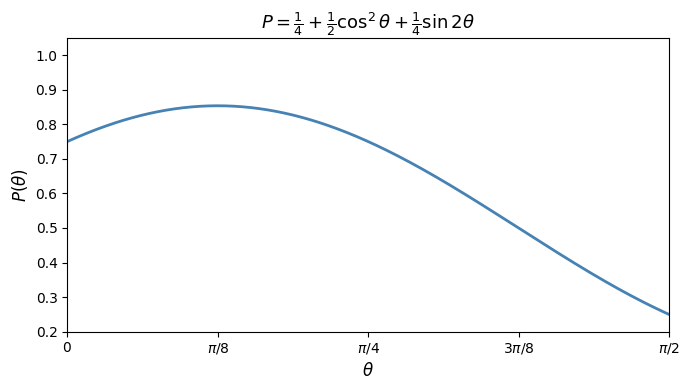

In [36]:
import matplotlib.pyplot as plt

theta = np.linspace(0, np.pi / 2, 500)

P = 0.25 + 0.5 * np.cos(theta)**2 + 0.25 * np.sin(2 * theta)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(theta, P, linewidth=2, color='steelblue')

# Axis labels using LaTeX
ax.set_xlabel(r'$\theta$', fontsize=12)
ax.set_ylabel(r'$P(\theta)$', fontsize=12)
ax.set_title(r'$P = \frac{1}{4} + \frac{1}{2}\cos^2\theta '
             r'+ \frac{1}{4}\sin 2\theta$', fontsize=13)

# x-axis ticks at meaningful angles
ax.set_xticks([0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2])
ax.set_xticklabels([r'$0$', r'$\pi/8$', r'$\pi/4$',
                    r'$3\pi/8$', r'$\pi/2$'])

ax.set_xlim(0, np.pi / 2)
ax.set_ylim(0.2, 1.05)
fig.tight_layout()
plt.show()


To verify this, we find the stationary point of $\mathbb{P}(\hat x = x)$ over $\theta\in[0, \frac{\pi}{2}]$:

$$
\begin{aligned}
\frac{d\mathbb{P}}{d\theta} &= -\cos\theta\sin\theta + \frac{1}{2}\cos2\theta \\
&= \frac{1}{2}\cos2\theta - \frac{1}{2}\sin2\theta.
\end{aligned}
$$ 
$$
\begin{aligned}
\frac{d\mathbb{P}}{d\theta} = 0 &\iff \sin2\theta = \cos2\theta \\
&\iff 2\theta = \frac{\pi}{4} \\
&\iff \theta = \frac{\pi}{8}.
\end{aligned}
$$

Hence, Eve maximises her chances of correctly guessing Alice's bit if she uses Breidbart basis ($\theta = \frac{\pi}{8}$). Using this basis, the probability of correctly guessing Alice's bit is $\mathbb{P}(\hat x = x)_{\theta = \frac{\pi}{8}} = \frac{1}{2} + \frac{1}{2\sqrt{2}} ≈ 0.8536$.

### **§5.3 - Comparing Attacks**

In [37]:
num_bits = 5000

random_attack_eve = RandomInterceptResendEve(rng=rng, seed=seed)
random_attack_results = run_bb84(num_bits, channel=random_attack_eve, sample_qber_fraction=0.2,rng=rng)
random_attack_alice_bits = random_attack_results.alice_bits

breidbart_attack_eve = BreidbartEve(rng=rng, seed=seed)
breidbart_attack_results = run_bb84(num_bits, channel=breidbart_attack_eve, sample_qber_fraction=0.2, rng=rng)
breidbart_attack_alice_bits = breidbart_attack_results.alice_bits

random_pcorrect = np.mean(random_attack_alice_bits == random_attack_eve.attack_record.eve_bits)
breidbart_pcorrect = np.mean(breidbart_attack_alice_bits == breidbart_attack_eve.attack_record.eve_bits)

print(f"Empirical P(Eve Guesses Correctly)")
print("----------------------------------")
print(f"Random attack:     {random_pcorrect:.2%}")
print(f"Breidbart attack:  {breidbart_pcorrect:.2%}")

Empirical P(Eve Guesses Correctly)
----------------------------------
Random attack:     75.78%
Breidbart attack:  85.12%


Indeed, our empircal results closely match the theoretical probablities derived in the above section.

### **Appendix - Proof of No-Cloning Theorem**

Let $S$ be a set of quantum states containing at least one non-orthogonal pair and assume $\exists$ a unitary cloning process that achieves cloning $\forall$ states in $S$. 

Let $|\psi\rangle$ & $|\phi\rangle \in S$ be non-orthogonal and distinct. The unitary cloning process for each of these states would then proceed as follows: 

$$U(|\psi\rangle |\alpha_0\rangle |A_0\rangle) = |\psi\rangle |\psi\rangle |A_\psi\rangle$$
$$U(|\phi\rangle |\alpha_0\rangle |A_0\rangle) = |\phi\rangle |\phi\rangle |A_\phi\rangle$$

where $U$ is the unitary cloning operator, $|\alpha_0\rangle$ is the initial state of the system we are cloning on to and $|A_0\rangle$ & $|A_{\psi /\phi}\rangle$ are ancillary states encompassing the state of the cloning device before and after cloning. Now taking the inner product of the above expressions:
$$ (\langle\psi|\langle\alpha_0|\langle A_0|)U^{\dagger}U(|\psi\rangle |\alpha_0\rangle |A_0\rangle) = \langle\psi|\phi\rangle \langle\psi|\phi\rangle \langle A_\psi | A_\phi\rangle $$
 $$\Rightarrow \langle\psi|\phi\rangle \langle\alpha_0|\alpha_0\rangle \langle A_0|A_0 \rangle = \langle\psi|\phi\rangle^2\langle A_\psi | A_\phi\rangle$$ $$\Rightarrow \langle\psi|\phi\rangle = \langle\psi|\phi\rangle^2\langle A_\psi | A_\phi\rangle$$

Now, $|\psi\rangle$ & $|\phi\rangle$ non-orthogonal $\Rightarrow \langle\psi|\phi\rangle ≠ 0$ and hence: 

$$1 = \langle\psi|\phi\rangle \langle A_\psi | A_\phi\rangle$$

However, $|\psi\rangle$ & $|\phi\rangle$ distinct $\Rightarrow |\langle\psi|\phi\rangle| < 1 \Rightarrow |\langle A_\psi | A_\phi\rangle| > 1$ which contradicts normalisation. Hence we conclude that no such unitary cloning process can exist  $\blacksquare$
